In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from PyEMD import EMD  # pip install PyEMD

#%matplotlib inline

In [ ]:
#%pip install EMD-signal


   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ----- ---------------------------------- 1/7 [ppft]
   ----- ---------------------------------- 1/7 [ppft]
   ----- ---------------------------------- 1/7 [ppft]
   ----------- ---------------------------- 2/7 [pox]
   ----------- ---------------------------- 2/7 [pox]
   ----------------- ---------------------- 3/7 [dill]
   ----------------- ---------------------- 3/7 [dill]
   ----------------- ---------------------- 3/7 [dill]
   ----------------- ---------------------- 3/7 [dill]
   ----------------- ---------------------- 3/7 [dill]
   ----------------- ---------------------- 3/7 [dill]
   ---------------------- ----------------- 4/7 [multiprocess]
   ---------------------- ----------------- 4/7 [multiprocess]
   ---------------------- ----------------- 4/7 [multiprocess]
   ---------------------- ----------------

In [17]:
def estimate_period_fft(series, default_period=24):
    """
    FFT를 활용하여 시계열 데이터에서 가장 지배적인 주기를 동적으로 추정합니다.
    """
    n = len(series)
    t = np.arange(n)
    
    # 1. FFT 전처리: 선형 추세 및 평균(DC 성분) 제거
    p = np.polyfit(t, series, 1)
    detrended = series - np.polyval(p, t)
    detrended = detrended - np.mean(detrended)
    
    # 2. FFT 수행 및 진폭 계산
    fft_vals = np.fft.rfft(detrended)
    frequencies = np.fft.rfftfreq(n)
    magnitudes = np.abs(fft_vals)
    
    # 3. 0Hz(상수항)를 제외하고 진폭이 가장 큰 인덱스 탐색
    if len(magnitudes) > 1:
        dominant_idx = np.argmax(magnitudes[1:]) + 1 
        dominant_freq = frequencies[dominant_idx]
        
        if dominant_freq > 0:
            period = int(np.round(1.0 / dominant_freq))
            if 2 <= period <= n // 2:
                return period
                
    return default_period

def calculate_3d_metrics(series):
    """
    FFT 기반 동적 주기 추출 후, STL 분해와 EMD를 결합하여 
    독립적 신호 대 잡음비(SNR) 기반의 F_T, F_S, F_I 지표를 산출합니다.
    """
    estimated_p = estimate_period_fft(series)
    
    if len(series) < 2 * estimated_p:
        estimated_p = max(2, len(series) // 2 - 1)
        
    try:
        # 1. STL 분해 (T, S, R_stl 도출)
        res = STL(series, period=estimated_p, robust=True).fit()
        T, S, R_stl = res.trend, res.seasonal, res.resid
        
        # 2. EMD 분해 (Residual을 다시 분해하여 Intervention 추출)
        emd = EMD()
        imfs = emd.emd(R_stl)
        
        # IMF 성분 중 노이즈(IMF1)와 최저주파 잔차를 제외한 중간 대역을 I(Intervention)로 정의
        if len(imfs) > 2:
            I = np.sum(imfs[1:-1], axis=0) 
        elif len(imfs) == 2:
            I = imfs[1]
        else:
            I = np.zeros_like(R_stl)
            
        # ★ 3. 순수 노이즈(R_pure) 도출: STL 잔차에서 EMD로 찾은 개입 성분(I) 차감
        R_pure = R_stl - I
        
        # ★ 4. 3차원 강도 산출 (독립적 신호 대 잡음비 방식 적용)
        var_R = np.var(R_pure)
        
        var_TR = np.var(T + R_pure)
        var_SR = np.var(S + R_pure)
        var_IR = np.var(I + R_pure)
        
        # Hyndman 공리 기반의 성분별 직교(Orthogonal) 강도 계산
        F_T = max(0.0, 1.0 - (var_R / var_TR if var_TR > 0 else 1.0))
        F_S = max(0.0, 1.0 - (var_R / var_SR if var_SR > 0 else 1.0))
        F_I = max(0.0, 1.0 - (var_R / var_IR if var_IR > 0 else 1.0))
        
    except Exception:
        # 분해 실패 시 예외 처리 (정상성 노이즈로 간주)
        F_T, F_S, F_I = 0.0, 0.0, 0.0
        
    return F_T, F_S, F_I, estimated_p

def generate_extensive_synthetic_dataset(n_samples_per_q=50, length=500):
    """
    4사분면 검증을 위해 통계적 특성이 다양한 복잡한 가상 시계열 데이터를 대량 생성합니다.
    """
    data_records = []
    t = np.arange(length)
    
    for i in range(n_samples_per_q):
        print(f"💡 Generating sample {i+1}/{n_samples_per_q} for each regime...")
        
        rand_p1 = np.random.choice([12, 24, 36, 48])
        rand_p2 = rand_p1 * 2
        
        # --- R1: Composite Regime ---
        slope = np.random.uniform(0.1, 0.4) * np.random.choice([1, -1])
        curve = np.random.uniform(1e-5, 5e-5) * np.random.choice([1, -1])
        amp1, amp2 = np.random.uniform(8, 25), np.random.uniform(2, 8)
        noise_std = np.random.uniform(0.5, 1.5)
        
        q1_series = (slope * t + curve * (t**2)) + (amp1 * np.sin(2 * np.pi * t / rand_p1)) + (amp2 * np.cos(2 * np.pi * t / rand_p2)) + np.random.normal(0, noise_std, length)
        q1_scaled = (q1_series - np.min(q1_series)) / (np.max(q1_series) - np.min(q1_series) + 1e-9)
        ft, fs, fi, p_est = calculate_3d_metrics(q1_scaled)
        
        data_records.append({'True_Regime': 'R1', 'Pattern': 'Trend+MultiSeason', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': rand_p1, 'Est_P': p_est})
        
        # --- R2: Pure Seasonal ---
        amp1, amp2 = np.random.uniform(10, 30), np.random.uniform(4, 12)
        noise_std = np.random.uniform(0.5, 2.0)
        
        q2_series = (amp1 * np.sin(2 * np.pi * t / rand_p1)) + (amp2 * np.cos(2 * np.pi * t / rand_p2)) + np.random.normal(0, noise_std, length)
        q2_scaled = (q2_series - np.min(q2_series)) / (np.max(q2_series) - np.min(q2_series) + 1e-9)
        ft, fs, fi, p_est = calculate_3d_metrics(q2_scaled)
        
        data_records.append({'True_Regime': 'R2', 'Pattern': 'Pure_MultiSeason', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': rand_p1, 'Est_P': p_est})
        
        # --- R3: Stationary / Noise ---
        noise_type = np.random.choice(['WN', 'AR'])
        if noise_type == 'WN':
            q3_series = np.random.normal(0, np.random.uniform(5, 15), length)
        else:
            phi_val = np.random.uniform(0.4, 0.7)
            q3_series = np.zeros(length)
            innovations = np.random.normal(0, 5.0, length)
            q3_series[0] = innovations[0]
            for idx in range(1, length):
                q3_series[idx] = phi_val * q3_series[idx-1] + innovations[idx]
                
        q3_scaled = (q3_series - np.min(q3_series)) / (np.max(q3_series) - np.min(q3_series) + 1e-9)
        ft, fs, fi, p_est = calculate_3d_metrics(q3_scaled)
        
        data_records.append({'True_Regime': 'R3', 'Pattern': f'Stationary_{noise_type}', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': 'None', 'Est_P': p_est})

        # --- R4: Pure Trending (with Structural Breaks & Drifts) ---
        trend_type = np.random.choice(['Break', 'RandomWalk', 'Exponential'])
        noise_std = np.random.uniform(0.5, 1.5)
        
        if trend_type == 'Break':
            bp_val = length // 2
            q4_series = np.random.normal(0, noise_std, length)
            q4_series[bp_val:] += np.random.uniform(50, 150)
        elif trend_type == 'RandomWalk':
            drift_val = np.random.uniform(0.1, 0.5) * np.random.choice([1, -1])
            q4_series = np.cumsum(np.random.normal(drift_val, 2, length))
        else:
            q4_series = np.exp(np.linspace(0, np.random.uniform(3, 5), length)) + np.random.normal(0, noise_std, length)

        q4_scaled = (q4_series - np.min(q4_series)) / (np.max(q4_series) - np.min(q4_series) + 1e-9)
        ft, fs, fi, p_est = calculate_3d_metrics(q4_scaled)
        
        data_records.append({'True_Regime': 'R4', 'Pattern': f'PureTrend_{trend_type}', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': 'None', 'Est_P': p_est})
        
    return pd.DataFrame(data_records)


In [ ]:
# ==========================================
# 1. 데이터 생성 실행 (테스트용 샘플 10개)
# ==========================================
df_exp_results = generate_extensive_synthetic_dataset(n_samples_per_q=2000, length=500)

💡 Generating sample 1/2000 for each regime...
💡 Generating sample 2/2000 for each regime...
💡 Generating sample 3/2000 for each regime...
💡 Generating sample 4/2000 for each regime...
💡 Generating sample 5/2000 for each regime...
💡 Generating sample 6/2000 for each regime...
💡 Generating sample 7/2000 for each regime...
💡 Generating sample 8/2000 for each regime...
💡 Generating sample 9/2000 for each regime...
💡 Generating sample 10/2000 for each regime...
💡 Generating sample 11/2000 for each regime...
💡 Generating sample 12/2000 for each regime...
💡 Generating sample 13/2000 for each regime...
💡 Generating sample 14/2000 for each regime...
💡 Generating sample 15/2000 for each regime...
💡 Generating sample 16/2000 for each regime...
💡 Generating sample 17/2000 for each regime...
💡 Generating sample 18/2000 for each regime...
💡 Generating sample 19/2000 for each regime...
💡 Generating sample 20/2000 for each regime...
💡 Generating sample 21/2000 for each regime...
💡 Generating sample 22

In [ ]:
df_exp_results.to_csv('../../results/temp/0705_per2000len500_synthetic_dataset.csv', index=False)

#df_exp_results

,True_Regime,Pattern,F_T,F_S,F_I,True_P,Est_P
0,R1,Trend+MultiSeason,0.996771,0.993056,0.887110,36,36
1,R2,Pure_MultiSeason,0.905464,0.997437,0.922672,36,36
2,R3,Stationary_AR,0.123355,0.552922,0.608313,None,36
3,R4,PureTrend_Break,0.999969,0.999874,0.000000,None,250
4,R1,Trend+MultiSeason,0.999866,0.998852,0.936621,12,12
...,...,...,...,...,...,...,...
39995,R4,PureTrend_Exponential,0.989259,0.406195,0.366114,None,24
39996,R1,Trend+MultiSeason,0.999354,0.995929,0.914026,48,50
39997,R2,Pure_MultiSeason,0.984738,0.998190,0.987823,48,50
39998,R3,Stationary_AR,0.416916,0.637549,0.732772,None,42


In [18]:
df_exp_results = pd.read_csv('../../results/temp/synthetic_quadrant_dataset_per10000len500_0702.csv')

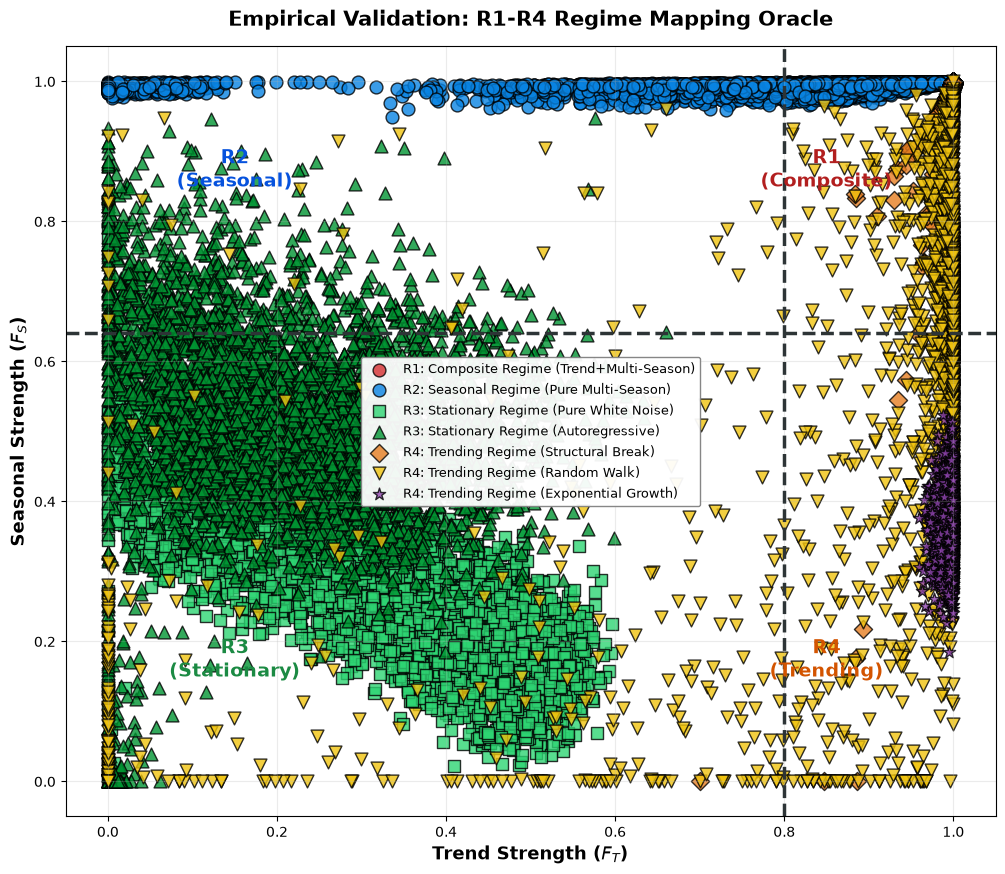


     [오라클 검증 통계 리포트 (임계치: 0.64)]
▶ R1: Composite Regime
  - 생성 패턴 예시: <ArrowStringArray>['Trend+MultiSeason']Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.999 | Mean F_S = 0.995
  - FFT 주기 추정 정확도: 74.7%
  - 사분면 매핑 성공률 : [ 10000 / 10000 ] (100.0%)
------------------------------------------------------------
▶ R2: Seasonal Regime
  - 생성 패턴 예시: <ArrowStringArray>['Pure_MultiSeason']Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.845 | Mean F_S = 0.995
  - FFT 주기 추정 정확도: 73.6%
  - 사분면 매핑 성공률 : [ 2136 / 10000 ] (21.4%)
------------------------------------------------------------
▶ R3: Stationary Regime
  - 생성 패턴 예시: <ArrowStringArray>['Stationary_AR', 'Stationary_WN']Length: 2, dtype: str
  - 평균 지표값  : Mean F_T = 0.264 | Mean F_S = 0.392
  - 사분면 매핑 성공률 : [ 9227 / 10000 ] (92.3%)
------------------------------------------------------------
▶ R4: Trending Regime
  - 생성 패턴 예시: <ArrowStringArray>['PureTrend_Break', 'PureTrend_RandomWalk', 'PureTrend_Exponential']Length: 3, dtype: str
  - 평

INFO: pip is looking at multiple versions of plotly to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of plotly to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ---------------------------------------- 0.0/19.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.1 MB ? eta -:--:--
    --------------------------------------- 0.3/19.1 MB ? eta -:--:--
    --------------------------------------- 0.3/19.1 MB ? eta -:--:--
    --------------------------------------- 0.

In [ ]:
# ==========================================
# 2. 결과 시각화 (R1~R4 범례 순서 고정 및 세부 패턴 플롯팅)
# ==========================================
F_T_thr = 0.80
F_S_thr = 0.64

plt.figure(figsize=(12, 10))

# 1. 학술적 일관성을 위해 패턴별 고유 시각 세팅 테이블 정의
pattern_configs = {
    'Trend+MultiSeason':       {'color': '#d63031', 'marker': 'o', 'label': 'R1: Composite'},
    'Pure_MultiSeason':        {'color': '#0984e3', 'marker': 'o', 'label': 'R2: Seasonal'},
    'Stationary_WN':           {'color': '#2ed573', 'marker': 's', 'label': 'R3: Stationary-WN (WN)'},
    'Stationary_AR':           {'color': '#009432', 'marker': '^', 'label': 'R3: Stationary-AR)'},
    'PureTrend_Break':         {'color': '#e67e22', 'marker': 'D', 'label': 'R4: Trending-Mean Shift)'},
    'PureTrend_RandomWalk':    {'color': '#f1c40f', 'marker': 'v', 'label': 'R4: Trending-Random Walk with Shift'},
    'PureTrend_Exponential':   {'color': '#8e44ad', 'marker': '*', 'label': 'R4: Trending-Exponential Growth'}
}

# 2. 범례 순서를 R1 -> R2 -> R3 -> R4 순으로 강제 정렬하기 위한 마스터 맵 순서 선언
legend_order = [
    'Trend+MultiSeason',
    'Pure_MultiSeason',
    'Stationary_WN',
    'Stationary_AR',
    'PureTrend_Break',
    'PureTrend_RandomWalk',
    'PureTrend_Exponential'
]

# 3. 데이터프레임 내에 존재하는 패턴만 필터링하여 순서대로 플롯팅 (범례 순서 꼬임 원천 차단)
existing_patterns = [p for p in legend_order if p in df_exp_results['Pattern'].unique()]

for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x', 'label': pattern_label})
    
    plt.scatter(group['F_T'], group['F_S'], 
                label=config['label'], color=config['color'], marker=config['marker'],
                alpha=0.8, edgecolors='k', s=85)

# 오라클 결정 가이드라인 경계선 (tau = 0.64)
plt.axvline(x=F_T_thr, color='#2d3436', linestyle='--', linewidth=2.5)
plt.axhline(y=F_S_thr, color='#2d3436', linestyle='--', linewidth=2.5)

# 사분면 텍스트 표기
plt.text(0.85, 0.85, 'R1\n(Composite)', fontsize=14, fontweight='bold', ha='center', color='#b21f1f')
plt.text(0.15, 0.85, 'R2\n(Seasonal)', fontsize=14, fontweight='bold', ha='center', color='#0652dd')
plt.text(0.15, 0.15, 'R3\n(Stationary)', fontsize=14, fontweight='bold', ha='center', color='#1b8a43')
plt.text(0.85, 0.15, 'R4\n(Trending)', fontsize=14, fontweight='bold', ha='center', color='#d35400')

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Trend Strength ($F_T$)', fontsize=13, fontweight='bold')
plt.ylabel('Seasonal Strength ($F_S$)', fontsize=13, fontweight='bold')
plt.title('Empirical Validation: R1-R4 Regime Mapping Oracle', fontsize=15, fontweight='bold', pad=15)

# 범례 정중앙 위치 설정 (가독성을 위한 반투명 흰색 배경막 장착)
plt.legend(loc='center', fontsize=9.5, framealpha=0.95, facecolor='white', edgecolor='gray')
plt.grid(True, alpha=0.25)
plt.show()

# ==========================================
# 3. 오라클 분류 정확도 결산 리포트 출력
# ==========================================
print("\n" + "="*60)
print("     [오라클 검증 통계 리포트 (임계치: 0.64)]")
print("="*60)

regime_names = {'R1': 'Composite Regime', 'R2': 'Seasonal Regime', 'R3': 'Stationary Regime', 'R4': 'Trending Regime'}

total_success = 0
# 데이터셋 내의 고유 레짐 라벨을 기준으로 루프 실행
for r_label in ['R1', 'R2', 'R3', 'R4']:
    sub_df = df_exp_results[df_exp_results['True_Regime'] == r_label]
    
    # 사분면 조건문 (R1~R4 로직 반영)
    if r_label == 'R1':
        success_condition = (sub_df['F_T'] >= F_T_thr) & (sub_df['F_S'] >= F_S_thr)
    elif r_label == 'R2':
        success_condition = (sub_df['F_T'] < F_T_thr) & (sub_df['F_S'] >= F_S_thr)
    elif r_label == 'R3':
        success_condition = (sub_df['F_T'] < F_T_thr) & (sub_df['F_S'] < F_S_thr)
    elif r_label == 'R4':
        success_condition = (sub_df['F_T'] >= F_T_thr) & (sub_df['F_S'] < F_S_thr)
        
    success_count = len(sub_df[success_condition])
    total_success += success_count
    accuracy = (success_count / len(sub_df)) * 100
    
    unique_patterns = list(sub_df['Pattern'].unique())
    print(f"▶ {r_label}: {regime_names[r_label]}")
    print(f"  - 생성 패턴 예시: <ArrowStringArray>{unique_patterns}Length: {len(unique_patterns)}, dtype: str")
    print(f"  - 평균 지표값  : Mean F_T = {sub_df['F_T'].mean():.3f} | Mean F_S = {sub_df['F_S'].mean():.3f}")
    
    # 주기 매칭 검증 (R1, R2에 대해서만 추출 성과 체크)
    if r_label in ['R1', 'R2']:
        same_p_count = len(sub_df[sub_df['True_P'] == sub_df['Est_P']])
        p_match_rate = (same_p_count / len(sub_df)) * 100
        print(f"  - FFT 주기 추정 정확도: {p_match_rate:.1f}%")
        
    print(f"  - 사분면 매핑 성공률 : [ {success_count} / {len(sub_df)} ] ({accuracy:.1f}%)")
    print("-" * 60)

print(f"■ 전체 통합 오라클 라우팅 정확도: {(total_success / len(df_exp_results))*100:.2f}%")
print("="*60)

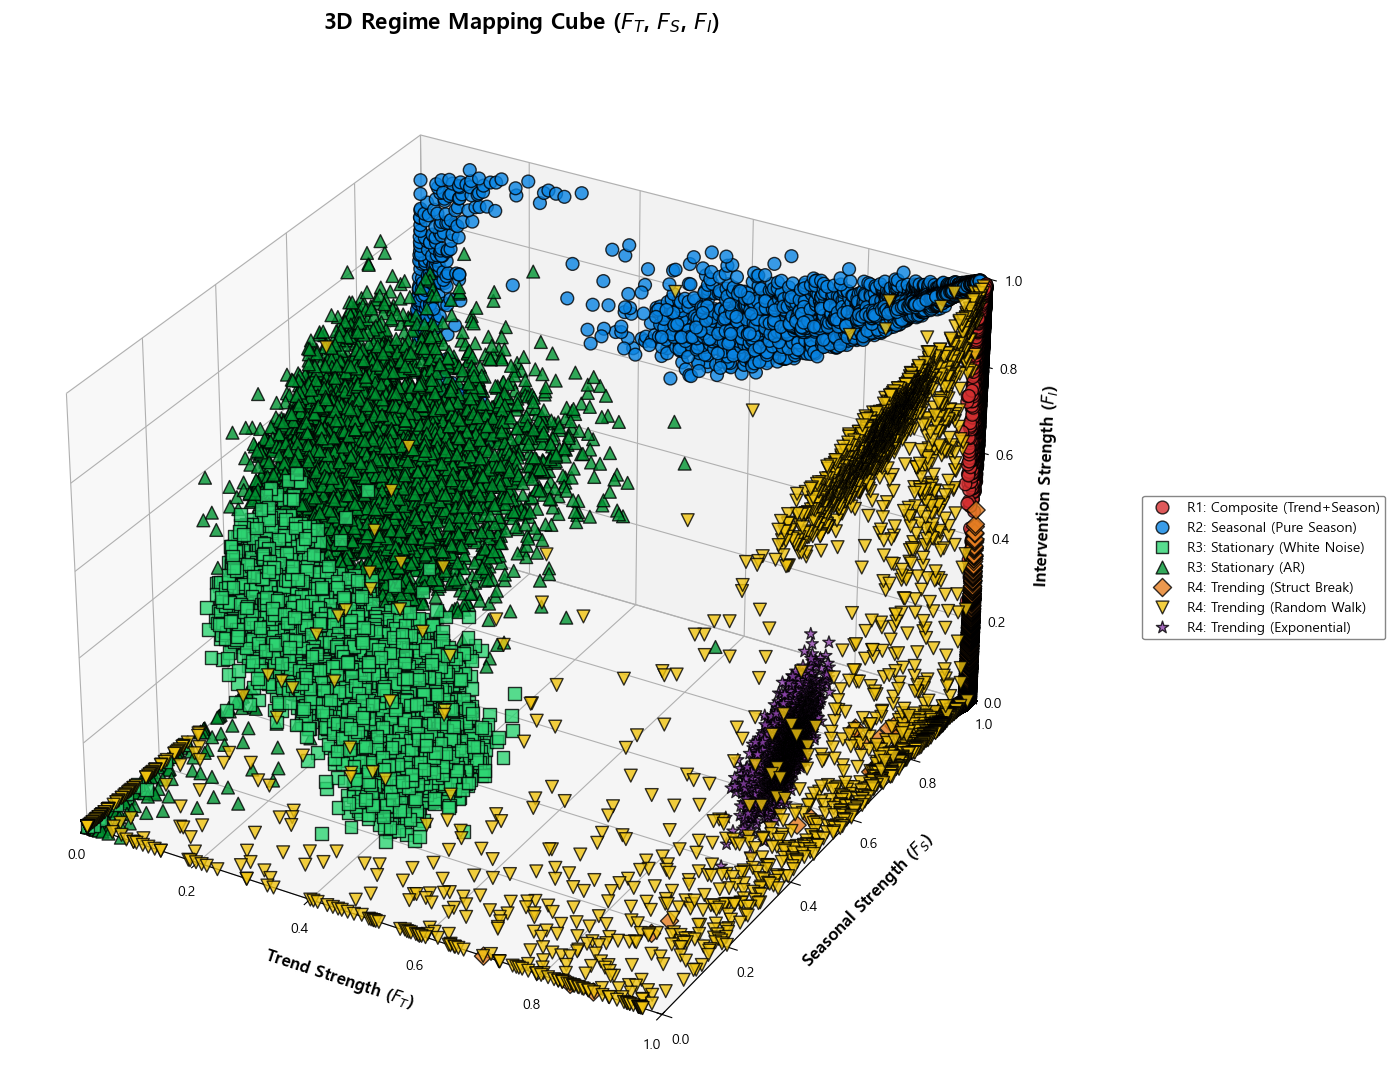


     [오라클 검증 통계 리포트 (3D 확장판 - 직교성 반영)]
▶ R1 Regime 평균 지표값
   F_T: 0.999 | F_S: 0.995 | F_I: 0.862
▶ R2 Regime 평균 지표값
   F_T: 0.845 | F_S: 0.995 | F_I: 0.896
▶ R3 Regime 평균 지표값
   F_T: 0.264 | F_S: 0.392 | F_I: 0.429
▶ R4 Regime 평균 지표값
   F_T: 0.971 | F_S: 0.666 | F_I: 0.307
   -> (R4 내부 상세 F_I 분석)
      PureTrend_Break: F_I = 0.021
      PureTrend_RandomWalk: F_I = 0.568
      PureTrend_Exponential: F_I = 0.339


In [7]:
# ==========================================
# 2. 결과 시각화 (3D Cube Mapping)
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # 환경에 따라 'AppleGothic' 등으로 변경 필요
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(14, 11))
ax = fig.add_subplot(111, projection='3d')

# 패턴별 색상 및 마커
pattern_configs = {
    'Trend+MultiSeason':       {'color': '#d63031', 'marker': 'o', 'label': 'R1: Composite (Trend+Season)'},
    'Pure_MultiSeason':        {'color': '#0984e3', 'marker': 'o', 'label': 'R2: Seasonal (Pure Season)'},
    'Stationary_WN':           {'color': '#2ed573', 'marker': 's', 'label': 'R3: Stationary (White Noise)'},
    'Stationary_AR':           {'color': '#009432', 'marker': '^', 'label': 'R3: Stationary (AR)'},
    'PureTrend_Break':         {'color': '#e67e22', 'marker': 'D', 'label': 'R4: Trending (Struct Break)'},
    'PureTrend_RandomWalk':    {'color': '#f1c40f', 'marker': 'v', 'label': 'R4: Trending (Random Walk)'},
    'PureTrend_Exponential':   {'color': '#8e44ad', 'marker': '*', 'label': 'R4: Trending (Exponential)'}
}

legend_order = list(pattern_configs.keys())
existing_patterns = [p for p in legend_order if p in df_exp_results['Pattern'].unique()]

# 3D 산점도 플로팅
for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs[pattern_label]
    
    ax.scatter(group['F_T'], group['F_S'], group['F_I'], 
               label=config['label'], color=config['color'], marker=config['marker'],
               alpha=0.8, edgecolors='k', s=85)

# 축 레이블 및 세팅
ax.set_xlabel('Trend Strength ($F_T$)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Seasonal Strength ($F_S$)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('Intervention Strength ($F_I$)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_title('3D Regime Mapping Cube ($F_T$, $F_S$, $F_I$)', fontsize=16, fontweight='bold', pad=20)

# 범례 설정 (그래프 바깥쪽)
ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize=10, framealpha=0.95, facecolor='white', edgecolor='gray')

plt.tight_layout()
plt.show()

# ==========================================
# 3. 간단한 리포트 (F_I 지표 평균 확인용)
# ==========================================
print("\n" + "="*60)
print("     [오라클 검증 통계 리포트 (3D 확장판 - 직교성 반영)]")
print("="*60)
for r_label in ['R1', 'R2', 'R3', 'R4']:
    sub_df = df_exp_results[df_exp_results['True_Regime'] == r_label]
    print(f"▶ {r_label} Regime 평균 지표값")
    print(f"   F_T: {sub_df['F_T'].mean():.3f} | F_S: {sub_df['F_S'].mean():.3f} | F_I: {sub_df['F_I'].mean():.3f}")
    if r_label == 'R4':
        print("   -> (R4 내부 상세 F_I 분석)")
        for p in sub_df['Pattern'].unique():
            p_df = sub_df[sub_df['Pattern'] == p]
            print(f"      {p}: F_I = {p_df['F_I'].mean():.3f}")
print("="*60)

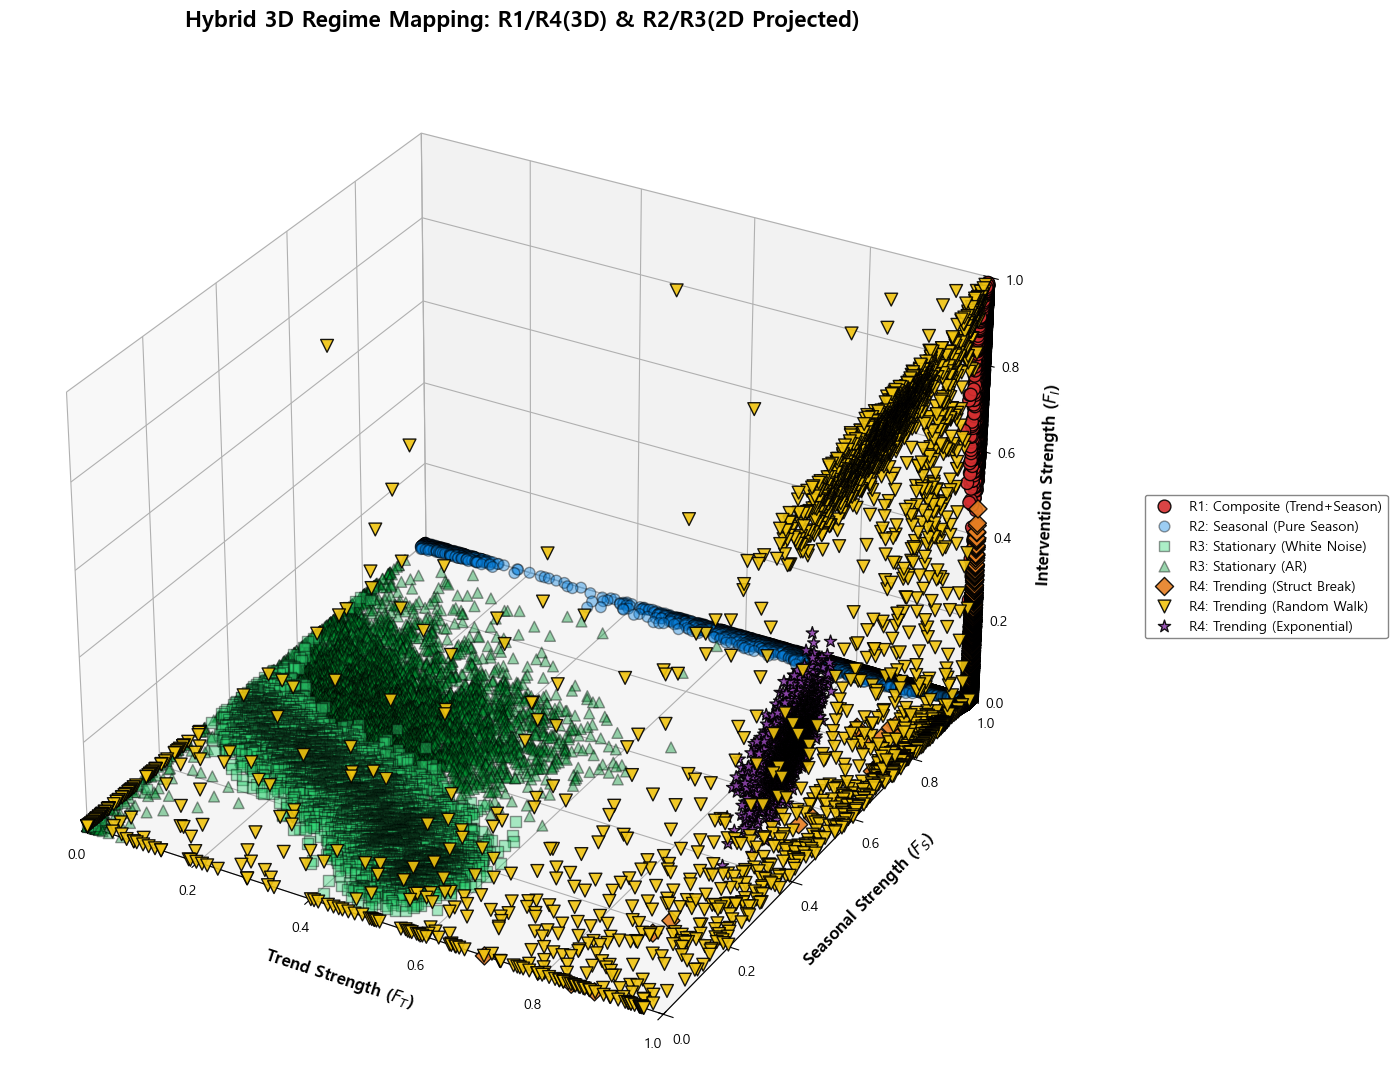


     [오라클 검증 통계 리포트 (3D 확장판 - 직교성 반영)]
▶ R1 Regime 평균 지표값
   F_T: 0.999 | F_S: 0.995 | F_I: 0.862
▶ R2 Regime 평균 지표값
   F_T: 0.845 | F_S: 0.995 | F_I: 0.896
▶ R3 Regime 평균 지표값
   F_T: 0.264 | F_S: 0.392 | F_I: 0.429
▶ R4 Regime 평균 지표값
   F_T: 0.971 | F_S: 0.666 | F_I: 0.307
   -> (R4 내부 상세 F_I 분석)
      PureTrend_Break: F_I = 0.021
      PureTrend_RandomWalk: F_I = 0.568
      PureTrend_Exponential: F_I = 0.339


In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 2. 결과 시각화 (3D/2D Hybrid Cube Mapping)
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(14, 11))
ax = fig.add_subplot(111, projection='3d')

# 패턴별 색상 및 마커 설정
pattern_configs = {
    'Trend+MultiSeason':       {'color': '#d63031', 'marker': 'o', 'label': 'R1: Composite (Trend+Season)'},
    'Pure_MultiSeason':        {'color': '#0984e3', 'marker': 'o', 'label': 'R2: Seasonal (Pure Season)'},
    'Stationary_WN':           {'color': '#2ed573', 'marker': 's', 'label': 'R3: Stationary (White Noise)'},
    'Stationary_AR':           {'color': '#009432', 'marker': '^', 'label': 'R3: Stationary (AR)'},
    'PureTrend_Break':         {'color': '#e67e22', 'marker': 'D', 'label': 'R4: Trending (Struct Break)'},
    'PureTrend_RandomWalk':    {'color': '#f1c40f', 'marker': 'v', 'label': 'R4: Trending (Random Walk)'},
    'PureTrend_Exponential':   {'color': '#8e44ad', 'marker': '*', 'label': 'R4: Trending (Exponential)'}
}

# R1, R4는 3D (F_I 고려), R2, R3는 2D (F_I=0 평면 투영)
for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs[pattern_label]
    
    # R1 또는 R4인 경우 3차원 시각화
    if 'R1' in group['True_Regime'].values[0] or 'R4' in group['True_Regime'].values[0]:
        ax.scatter(group['F_T'], group['F_S'], group['F_I'], 
                   label=config['label'], color=config['color'], marker=config['marker'],
                   alpha=0.9, edgecolors='k', s=85)
    # R2 또는 R3인 경우 Z=0 평면에 투영 시각화
    else:
        ax.scatter(group['F_T'], group['F_S'], np.zeros(len(group)), 
                   label=config['label'], color=config['color'], marker=config['marker'],
                   alpha=0.4, edgecolors='k', s=60) # 약간 투명하게 표시

# 축 레이블 및 세팅
ax.set_xlabel('Trend Strength ($F_T$)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Seasonal Strength ($F_S$)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('Intervention Strength ($F_I$)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_title('Hybrid 3D Regime Mapping: R1/R4(3D) & R2/R3(2D Projected)', fontsize=16, fontweight='bold', pad=20)

# 범례 설정
ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize=10, framealpha=0.95, facecolor='white', edgecolor='gray')

plt.tight_layout()
plt.show()

# ==========================================
# 3. 간단한 리포트 (F_I 지표 평균 확인용)
# ==========================================
print("\n" + "="*60)
print("     [오라클 검증 통계 리포트 (3D 확장판 - 직교성 반영)]")
print("="*60)
for r_label in ['R1', 'R2', 'R3', 'R4']:
    sub_df = df_exp_results[df_exp_results['True_Regime'] == r_label]
    print(f"▶ {r_label} Regime 평균 지표값")
    print(f"   F_T: {sub_df['F_T'].mean():.3f} | F_S: {sub_df['F_S'].mean():.3f} | F_I: {sub_df['F_I'].mean():.3f}")
    if r_label == 'R4':
        print("   -> (R4 내부 상세 F_I 분석)")
        for p in sub_df['Pattern'].unique():
            p_df = sub_df[sub_df['Pattern'] == p]
            print(f"      {p}: F_I = {p_df['F_I'].mean():.3f}")
print("="*60)

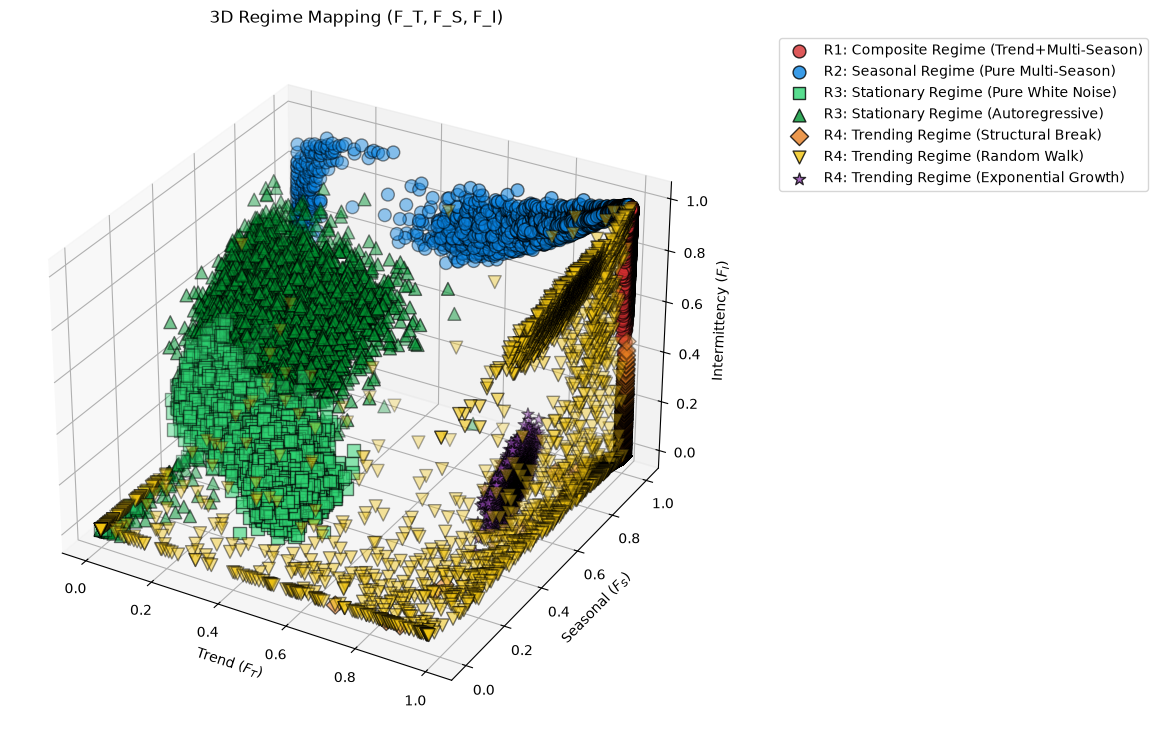

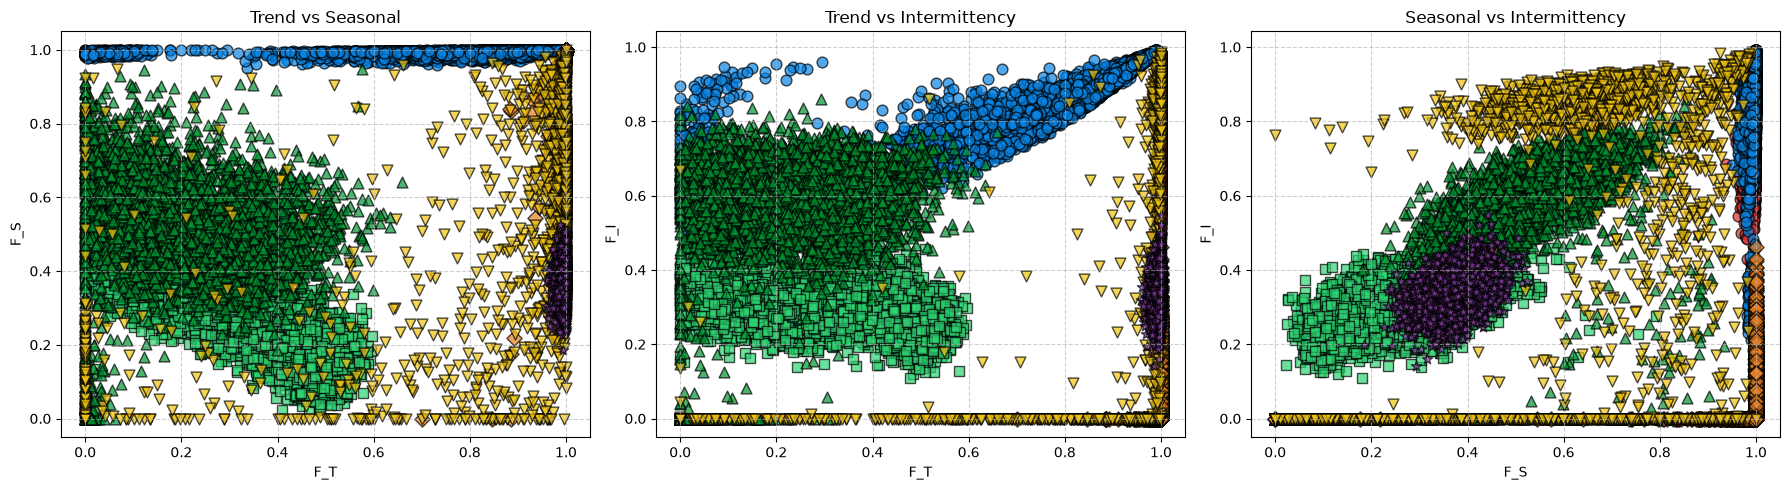

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 1. 3D 시각화 (F_T, F_S, F_I)
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x', 'label': pattern_label})
    
    ax.scatter(group['F_T'], group['F_S'], group['F_I'], 
               label=config['label'], color=config['color'], marker=config['marker'],
               alpha=0.8, edgecolors='k', s=85)

ax.set_xlabel('Trend ($F_T$)')
ax.set_ylabel('Seasonal ($F_S$)')
ax.set_zlabel('Intermittency ($F_I$)')
ax.set_title('3D Regime Mapping (F_T, F_S, F_I)')
ax.legend(bbox_to_anchor=(1.1, 1), loc='upper left')
plt.show()

# 2. 2차원 투영 평면 3종 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [('F_T', 'F_S'), ('F_T', 'F_I'), ('F_S', 'F_I')]
titles = ['Trend vs Seasonal', 'Trend vs Intermittency', 'Seasonal vs Intermittency']

for i, (x_col, y_col) in enumerate(pairs):
    ax = axes[i]
    for pattern_label in existing_patterns:
        group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
        config = pattern_configs.get(pattern_label)
        
        ax.scatter(group[x_col], group[y_col], 
                   label=config['label'], color=config['color'], marker=config['marker'],
                   alpha=0.7, edgecolors='k', s=60)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(titles[i])
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [26]:
import plotly.express as px
import plotly.graph_objects as go

# 1. 3D 인터랙티브 플롯 (F_T, F_S, F_I)
fig = px.scatter_3d(df_exp_results, x='F_T', y='F_S', z='F_I',
                    color='Pattern', symbol='Pattern',
                    title="3D Regime Mapping (Interactive)",
                    opacity=0.8, size_max=10)

fig.update_layout(scene=dict(
    xaxis_title='Trend (F_T)',
    yaxis_title='Seasonal (F_S)',
    zaxis_title='Intermittency (F_I)'
))
fig.show()

# 2. 2D 인터랙티브 플롯 모음 (F_T vs F_S, F_T vs F_I, F_S vs F_I)
pairs = [('F_T', 'F_S'), ('F_T', 'F_I'), ('F_S', 'F_I')]

for x_col, y_col in pairs:
    fig = px.scatter(df_exp_results, x=x_col, y=y_col,
                     color='Pattern', symbol='Pattern',
                     title=f"Interactive 2D Mapping: {x_col} vs {y_col}",
                     hover_data=['Pattern'])
    fig.show()

FileNotFoundError: Validator JSON file not found: c:\Users\wayne\Desktop\PythonProject\TSFM_Ops\.venv\Lib\site-packages\plotly\validators\_validators.json

In [25]:
!pip install plotly